# 04 — Synthetic linkage benchmark calibration

**Purpose.** This notebook analyses the real BOAMP corpus to estimate the structural
properties a *synthetic* linkage benchmark generator needs to reproduce: population
composition, field distributions, temporal change, buyer activity, identifier quality,
buyer-name variation, CPV quality, duration quality, procurement-text characteristics,
missingness dependencies, error co-occurrence, and candidate-environment complexity.

**Three-tier rule (applied throughout).** Every statistic in this notebook is tagged
with exactly one tier, recorded in the parameter-provenance inventory built in §16:

- **OBSERVABLE** — measured directly from raw BOAMP fields or the shared, layer-neutral
  preparation logic (`prepare_common`, `build_boamp_buyer_key`) applied to the *full*
  corpus. No candidate generation, scoring, or thresholding is involved.
- **SILVER_STANDARD** — visible only through Layer 1 (`boamp_only`) / Layer 2
  (`enriched`) *accepted links*. Confined entirely to §15, always caveated as
  conditional-on-acceptance, never presented as an unconditional or ground-truth rate.
- **UNIDENTIFIED** — cannot be estimated from any BOAMP output in this repo (there are
  zero completed manual-validation labels anywhere — `docs/methodology.md` §9). Listed
  in §14 as scenario knobs the synthetic generator should sweep, not calibrate to a point.

**This notebook must never claim:**
- the true recurrence prevalence of BOAMP buyers/contracts,
- the true precision/recall of the Layer 1/Layer 2 linkage pipeline,
- that the frozen thresholds (0.2642 / 0.3230 / 0.3931), the six-month temporal window,
  or the composite/component scores are empirical facts about the real world — they are
  the *pipeline's own modelling conventions*, not measurements.

Primary data source: **`data/interim/boamp_common_prepared.csv`** — the full corpus
(unfiltered by digital/ICT eligibility scope) after the shared, layer-neutral cleaning
step (`src/boamp/data/prepare.py::prepare_common` + `identity_boamp.build_boamp_buyer_key`).
This is *not* a linkage output: it runs once, before any candidate generation, and is
shared identically by both layers. Only §15 loads actual linkage outputs
(`data/processed/{boamp_only,enriched}/*`), and it is walled off from every other section.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from boamp.config import load_config
from boamp.reporting.figures import setup_style, save_figure
from boamp.data.identity_boamp import fragmentation_summary

cfg = load_config(PROJECT_ROOT)
setup_style()

TIER_COLORS = {"OBSERVABLE": "tab:blue", "SILVER_STANDARD": "tab:red", "UNIDENTIFIED": "tab:gray"}

provenance_rows = []

def add_provenance(parameter_id, parameter_name, tier, value_or_range, unit, stratification,
                    source_file, source_columns, computation_method, n_obs, section,
                    figure_or_table_ref, caveat):
    assert tier in TIER_COLORS
    assert caveat, "every provenance row must carry a non-empty caveat"
    provenance_rows.append(dict(
        parameter_id=parameter_id, parameter_name=parameter_name, tier=tier,
        value_or_range=value_or_range, unit=unit, stratification=stratification,
        source_file=source_file, source_columns=source_columns,
        computation_method=computation_method, n_obs=n_obs, notebook_section=section,
        figure_or_table_ref=figure_or_table_ref, caveat=caveat,
    ))

def add_tier_caveat_to_xlabel(ax, tier, caveat):
    label = ax.get_xlabel()
    prefix = f"{label}\n" if label else ""
    ax.set_xlabel(f"{prefix}[{tier}] {caveat}", fontsize=7, color=TIER_COLORS[tier])

print("Tier legend:", TIER_COLORS)
print("cfg.paths.interim_common_prepared =", cfg.paths.interim_common_prepared)

Tier legend: {'OBSERVABLE': 'tab:blue', 'SILVER_STANDARD': 'tab:red', 'UNIDENTIFIED': 'tab:gray'}
cfg.paths.interim_common_prepared = /home/senghakrou/survival-analysis/data/interim/boamp_common_prepared.csv


## 1. Data loading & tiering framework

Loads the full, layer-neutral prepared corpus. ID-like and CPV/department code columns
are read as strings (leading zeros in CPV divisions/department codes would otherwise be
lost to numeric coercion); date columns are parsed and made tz-naive, matching the
convention used throughout `notebooks/02_eda.ipynb`.

In [2]:
STR_COLS = {c: str for c in [
    "notice_id", "idweb", "id", "filename", "buyer_key", "buyer_key_type",
    "buyer_identifier_source", "cpv_clean", "cpv_main", "cpv_division", "cpv_group",
    "cpv_class", "cpv_category", "code_departement", "code_departement_prestation",
    "schema_family", "notice_type_normalized", "notice_type_raw", "buyer_siret_raw",
    "buyer_siret_clean", "buyer_siren_raw", "buyer_siren_clean", "buyer_name_raw",
    "buyer_name_normalized", "source_file", "raw_record_hash", "notice_id_raw",
    "duration_source_key", "duration_unit", "duration_quality_flag", "start_date_source",
    "category_label", "linked_attribution_notice_id", "famille", "famille_libelle",
    "type_marche", "type_marche_facette", "type_avis", "nature", "descripteur_code",
    "procedure_libelle", "type_procedure", "soustype_procedure", "perimetre", "etat",
    "annonce_lie", "titulaire",
]}
DATE_COLS = ["publication_date", "end_diffusion_date", "response_deadline",
             "start_date", "linked_attribution_date"]

common = pd.read_csv(cfg.paths.interim_common_prepared, low_memory=False,
                      dtype=STR_COLS, parse_dates=DATE_COLS)
common["dateparution"] = pd.to_datetime(common["dateparution"], errors="coerce",
                                         utc=True).dt.tz_localize(None)

assert common["notice_id"].is_unique, "notice_id must be unique in the prepared corpus"
common["dept_primary"] = common["code_departement"].fillna("").str.split(";").str[0].replace("", np.nan)

n_total = len(common)
year_min, year_max = int(common["publication_year"].min()), int(common["publication_year"].max())
print(f"Loaded {n_total:,} rows, {common.shape[1]} columns. "
      f"Publication years {year_min}-{year_max}.")

raw_flat = pd.read_csv(cfg.paths.interim_flattened, low_memory=False, dtype=str)
observed_cols_baseline = pd.read_csv(cfg.paths.reports_tables / "boamp_observed_columns.csv")
print(f"Raw flattened corpus (pre-dedup): {len(raw_flat):,} rows, {raw_flat.shape[1]} columns "
      f"(reference baseline: {len(observed_cols_baseline)} raw columns documented).")

add_provenance("n_total_notices", "Total notices in prepared corpus", "OBSERVABLE",
                n_total, "count", "unconditional", "data/interim/boamp_common_prepared.csv",
                "notice_id", "row count after dedup", n_total, "1",
                "n/a", "Full corpus, all sectors, all notice types, not scope-filtered.")

Loaded 84,623 rows, 95 columns. Publication years 2015-2026.
Raw flattened corpus (pre-dedup): 84,623 rows, 42 columns (reference baseline: 42 raw columns documented).


## 2. Population structure & corpus composition

Establishes the conditioning variables reused throughout: publication year, schema
family (LEGACY BOAMP-XSD vs. EFORMS post-Oct-2023 EU mandate), notice type, department,
and CPV division.

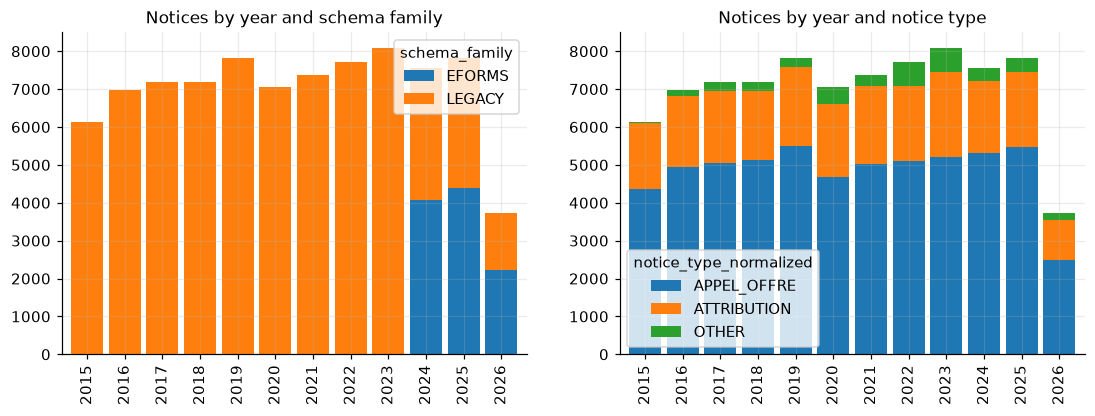

code_departement_prestation (place of performance) populated for 9.6% of notices.


,n_notices,share
code_departement,,
44,41880,0.494901
49,20368,0.240691
85,17630,0.208336
72,16162,0.190988
53,8661,0.102348
...,...,...
39,5,0.000059
976,2,0.000024
986,1,0.000012


In [3]:
by_year_schema = common.groupby(["publication_year", "schema_family"]).size().unstack(fill_value=0)
notice_type_by_year = common.groupby(["publication_year", "notice_type_normalized"]).size().unstack(fill_value=0)

dept_tokens = common["code_departement"].fillna("").str.split(";").explode()
dept_tokens = dept_tokens[dept_tokens != ""]
dept_coverage = dept_tokens.value_counts().rename("n_notices").to_frame()
dept_coverage["share"] = dept_coverage["n_notices"] / n_total
dept_prestation_rate = common["code_departement_prestation"].notna().mean()

cpv_division_coverage = common["cpv_division"].value_counts(dropna=False).rename("n_notices").to_frame()
cpv_division_coverage["share"] = cpv_division_coverage["n_notices"] / n_total

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
by_year_schema.plot(kind="bar", stacked=True, ax=axes[0], width=0.85)
axes[0].set_title("Notices by year and schema family"); axes[0].set_xlabel("")
notice_type_by_year.plot(kind="bar", stacked=True, ax=axes[1], width=0.85)
axes[1].set_title("Notices by year and notice type"); axes[1].set_xlabel("")
plt.show()
save_figure(fig, "calib_corpus_volume_by_year_schema", cfg)

by_year_schema.to_csv(cfg.paths.reports_tables / "calib_population_counts_by_year_schema.csv")
notice_type_by_year.to_csv(cfg.paths.reports_tables / "calib_notice_type_by_year.csv")
dept_coverage.to_csv(cfg.paths.reports_tables / "calib_department_coverage.csv")
cpv_division_coverage.to_csv(cfg.paths.reports_tables / "calib_cpv_division_coverage.csv")

print(f"code_departement_prestation (place of performance) populated for {dept_prestation_rate:.1%} of notices.")
display(dept_coverage)

add_provenance("dept_coverage", "Notice share by department (multi-valued, exploded)",
                "OBSERVABLE", "see table", "share", "marginal, by department",
                "data/interim/boamp_common_prepared.csv", "code_departement",
                "split on ';', explode, value_counts", n_total, "2",
                "calib_department_coverage.csv",
                "code_departement can list several departments per notice; shares sum to >1.")
add_provenance("notice_type_by_year", "Notice type composition by year", "OBSERVABLE",
                "see table", "count", "by year", "data/interim/boamp_common_prepared.csv",
                "notice_type_normalized, publication_year", "groupby crosstab", n_total, "2",
                "calib_notice_type_by_year.csv", "notice_type_normalized collapses rare types to OTHER.")

## 3. Field-level completeness (marginal & conditional)

Non-null rate for every column of the prepared corpus, computed fresh here rather than
reusing `reports/tables/boamp_observed_columns.csv` (which only covers the 42 raw
columns, not the ~50 derived ones this notebook needs). Key fields are then broken down
by year, schema family, and notice type — the three dimensions most associated with
completeness drift in BOAMP data.

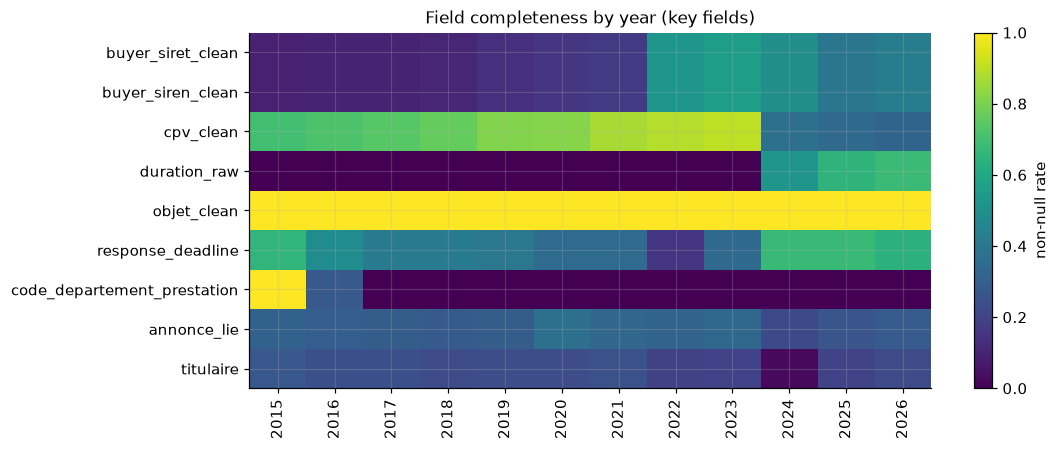

Lowest-completeness fields overall:


,dtype,non_null_rate,n_non_null
buyer_siren_raw,object,0.000000,0
siren_candidates_raw,float64,0.000000,0
soustype_procedure,object,0.005247,444
sousnature_libelle,object,0.064533,5461
code_departement_prestation,object,0.095872,8113
duration_unit,object,0.135011,11425
duration_months_raw,float64,0.136452,11547
duration_source_key,object,0.136452,11547
duration_raw,float64,0.136452,11547
declared_duration_months,float64,0.167874,14206


In [4]:
field_completeness_marginal = pd.DataFrame({
    "dtype": common.dtypes.astype(str),
    "non_null_rate": common.notna().mean(),
    "n_non_null": common.notna().sum(),
}).sort_values("non_null_rate")
field_completeness_marginal.to_csv(cfg.paths.reports_tables / "calib_field_completeness_marginal.csv")

KEY_FIELDS = ["buyer_siret_clean", "buyer_siren_clean", "cpv_clean", "duration_raw",
              "objet_clean", "response_deadline", "code_departement_prestation",
              "annonce_lie", "titulaire"]

completeness_by_year = common.groupby("publication_year")[KEY_FIELDS].apply(lambda d: d.notna().mean())
completeness_by_schema = common.groupby("schema_family")[KEY_FIELDS].apply(lambda d: d.notna().mean())
completeness_by_notice_type = common.groupby("notice_type_normalized")[KEY_FIELDS].apply(lambda d: d.notna().mean())

completeness_by_year.to_csv(cfg.paths.reports_tables / "calib_field_completeness_by_year.csv")
completeness_by_schema.to_csv(cfg.paths.reports_tables / "calib_field_completeness_by_schema.csv")
completeness_by_notice_type.to_csv(cfg.paths.reports_tables / "calib_field_completeness_by_notice_type.csv")

fig, ax = plt.subplots(figsize=(10, 4.2))
im = ax.imshow(completeness_by_year[KEY_FIELDS].T.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_yticks(range(len(KEY_FIELDS))); ax.set_yticklabels(KEY_FIELDS)
ax.set_xticks(range(len(completeness_by_year.index)))
ax.set_xticklabels(completeness_by_year.index, rotation=90)
ax.set_title("Field completeness by year (key fields)")
fig.colorbar(im, ax=ax, label="non-null rate")
plt.show()
save_figure(fig, "calib_field_completeness_heatmap", cfg)

print("Lowest-completeness fields overall:")
display(field_completeness_marginal.head(15))

add_provenance("field_completeness_marginal", "Non-null rate, all 94 columns", "OBSERVABLE",
                "see table", "rate", "marginal", "data/interim/boamp_common_prepared.csv",
                "all columns", "df.notna().mean()", n_total, "3",
                "calib_field_completeness_marginal.csv", "Includes both raw and derived columns.")
add_provenance("key_field_completeness_by_year", "Completeness of key fields by year",
                "OBSERVABLE", "see table", "rate", "by publication_year",
                "data/interim/boamp_common_prepared.csv", ",".join(KEY_FIELDS),
                "groupby year, notna mean", n_total, "3",
                "calib_field_completeness_heatmap.png", "Trend, not a validated forecast.")

## 4. Temporal change & schema transition (LEGACY → eForms)

Around October 2023 the EU eForms mandate changed the BOAMP notice schema
(`schema_family` LEGACY → EFORMS). This section isolates the completeness shift this
caused in the key fields, plus a finer quarterly trend around the transition.

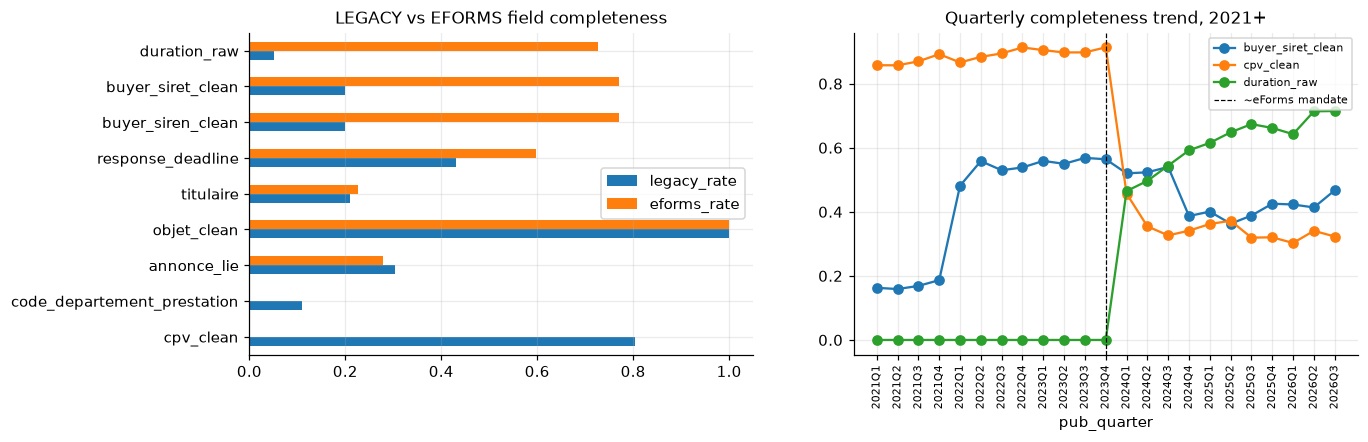

,legacy_rate,eforms_rate,delta_pp
cpv_clean,0.804736,0.000000,-80.473621
code_departement_prestation,0.109723,0.000000,-10.972262
annonce_lie,0.304500,0.278038,-2.646171
objet_clean,0.999986,1.000000,0.001352
titulaire,0.209775,0.226081,1.630590
response_deadline,0.431560,0.597922,16.636144
buyer_siren_clean,0.200227,0.770736,57.050861
buyer_siret_clean,0.200227,0.770736,57.050861
duration_raw,0.051284,0.725988,67.470351


In [5]:
legacy_rate = common.loc[common["schema_family"] == "LEGACY", KEY_FIELDS].notna().mean()
eforms_rate = common.loc[common["schema_family"] == "EFORMS", KEY_FIELDS].notna().mean()
schema_shift = pd.DataFrame({"legacy_rate": legacy_rate, "eforms_rate": eforms_rate})
schema_shift["delta_pp"] = (schema_shift["eforms_rate"] - schema_shift["legacy_rate"]) * 100
schema_shift = schema_shift.sort_values("delta_pp")
schema_shift.to_csv(cfg.paths.reports_tables / "calib_schema_transition_shift.csv")

common["pub_quarter"] = common["publication_date"].dt.to_period("Q").astype(str)
quarterly = common.groupby("pub_quarter")[["buyer_siret_clean", "cpv_clean", "duration_raw"]] \
                   .apply(lambda d: d.notna().mean())
quarterly = quarterly[(quarterly.index >= "2021Q1")]

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
schema_shift[["legacy_rate", "eforms_rate"]].plot(kind="barh", ax=axes[0])
axes[0].set_title("LEGACY vs EFORMS field completeness")
quarterly.plot(ax=axes[1], marker="o")
axes[1].axvline(quarterly.index.get_loc("2023Q4") if "2023Q4" in quarterly.index else 0,
                 color="k", ls="--", lw=0.8, label="~eForms mandate")
axes[1].set_xticks(range(len(quarterly.index)))
axes[1].set_xticklabels(quarterly.index, rotation=90, fontsize=7)
axes[1].set_title("Quarterly completeness trend, 2021+"); axes[1].legend(fontsize=7)
plt.show()
save_figure(fig, "calib_schema_transition_completeness", cfg)
display(schema_shift)

add_provenance("schema_transition_shift", "LEGACY vs EFORMS field completeness delta",
                "OBSERVABLE", "see table", "percentage points", "by schema_family",
                "data/interim/boamp_common_prepared.csv", ",".join(KEY_FIELDS),
                "groupby schema_family, notna mean, difference", n_total, "4",
                "calib_schema_transition_shift.csv",
                "schema_family is detected heuristically from the raw donnees payload (src/utils/boamp_schema.py); not a declared field.")

## 5. Buyer activity & concentration

Notices per `buyer_key` (BOAMP-native identity: SIRET > SIREN > normalized-name
fallback — see §6). Highly concentrated activity (a Zipf-like distribution) directly
determines candidate-block sizes a synthetic generator needs to reproduce. Defines a
`buyer_activity_tier` bucket reused as a conditioning variable in later sections.

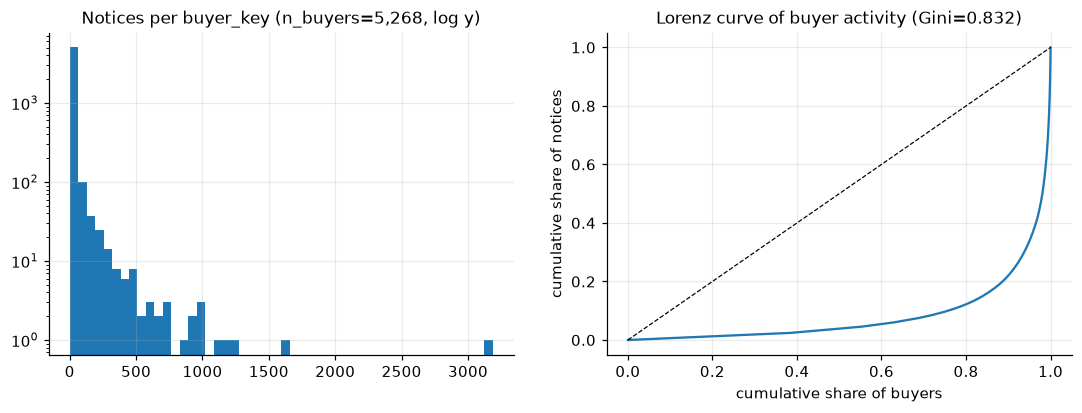

Gini coefficient of buyer activity: 0.832. Top-1 buyer share of all notices: 3.8%. Median notices/buyer: 2.


buyer_activity_tier
21+           68174
6-20           9339
2-5            5110
1 (single)     2000
Name: count, dtype: int64

In [6]:
buyer_counts = common.groupby("buyer_key").size().sort_values(ascending=False)
n_buyers = len(buyer_counts)

sorted_counts = buyer_counts.sort_values()
cum_notices = sorted_counts.cumsum() / sorted_counts.sum()
cum_buyers = np.arange(1, n_buyers + 1) / n_buyers
gini = 1 - 2 * np.trapezoid(cum_notices.values, cum_buyers)

bins = [0, 1, 5, 20, np.inf]
labels = ["1 (single)", "2-5", "6-20", "21+"]
tier_map = pd.cut(buyer_counts, bins=bins, labels=labels)
common["buyer_activity_tier"] = common["buyer_key"].map(tier_map).astype("object")
common["buyer_activity_tier"] = common["buyer_activity_tier"].fillna("NO_BUYER_KEY")

top_buyers = buyer_counts.head(20).rename("n_notices").to_frame()
name_lookup = common.dropna(subset=["buyer_key"]).groupby("buyer_key")["buyer_name_normalized"] \
                     .agg(lambda s: s.mode().iat[0] if not s.mode().empty else None)
top_buyers["buyer_name_normalized_mode"] = top_buyers.index.map(name_lookup)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].hist(buyer_counts, bins=50)
axes[0].set_yscale("log")
axes[0].set_title(f"Notices per buyer_key (n_buyers={n_buyers:,}, log y)")
axes[1].plot(cum_buyers, cum_notices)
axes[1].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[1].set_title(f"Lorenz curve of buyer activity (Gini={gini:.3f})")
axes[1].set_xlabel("cumulative share of buyers"); axes[1].set_ylabel("cumulative share of notices")
plt.show()
save_figure(fig, "calib_buyer_activity_distribution", cfg)

buyer_counts.rename("n_notices").to_csv(cfg.paths.reports_tables / "calib_buyer_activity_distribution.csv")
pd.DataFrame({"cum_share_buyers": cum_buyers, "cum_share_notices": cum_notices.values}) \
  .to_csv(cfg.paths.reports_tables / "calib_buyer_concentration_lorenz.csv", index=False)
top_buyers.to_csv(cfg.paths.reports_tables / "calib_top_buyers.csv")

print(f"Gini coefficient of buyer activity: {gini:.3f}. Top-1 buyer share of all notices: "
      f"{buyer_counts.iloc[0] / buyer_counts.sum():.1%}. Median notices/buyer: {buyer_counts.median():.0f}.")
display(common["buyer_activity_tier"].value_counts())

add_provenance("buyer_activity_gini", "Gini coefficient, notices per buyer_key", "OBSERVABLE",
                round(float(gini), 3), "unitless (0-1)", "unconditional",
                "data/interim/boamp_common_prepared.csv", "buyer_key",
                "Lorenz curve / Gini from groupby(buyer_key).size()", n_buyers, "5",
                "calib_buyer_activity_distribution.png",
                "buyer_key is BOAMP-native identity (SIRET/SIREN/name fallback); NAME_FALLBACK "
                "buyers aggregate multiple real entities under one key, inflating apparent concentration.")

## 6. Identifier quality (SIRET/SIREN)

Format- and checksum-valid rates for buyer SIRET/SIREN, and the provenance of the
identifier actually used (`buyer_identifier_source`), marginal and conditional.

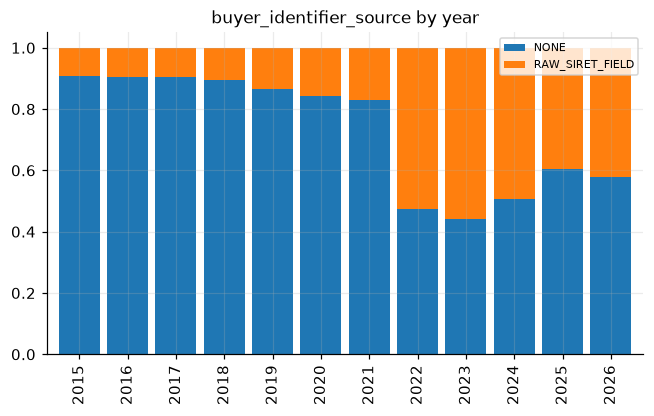

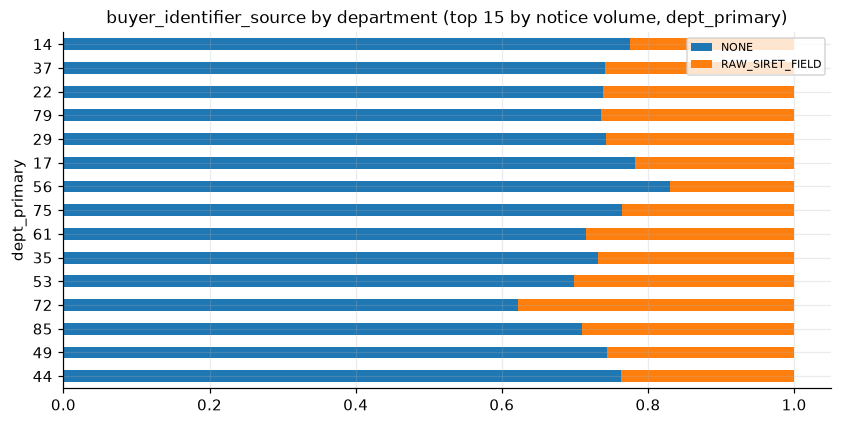

Identifier quality (marginal):


buyer_siret_format_valid      0.272243
buyer_siret_checksum_valid    0.271215
buyer_siren_format_valid      0.000000
buyer_siren_checksum_valid    0.000000
dtype: float64

Identifier source (marginal):


buyer_identifier_source
NONE               0.727757
RAW_SIRET_FIELD    0.272243
Name: proportion, dtype: float64

In [7]:
id_quality_summary = common[["buyer_siret_format_valid", "buyer_siret_checksum_valid",
                              "buyer_siren_format_valid", "buyer_siren_checksum_valid"]].mean()
id_source_counts = common["buyer_identifier_source"].value_counts(normalize=True)

id_source_by_year = common.groupby("publication_year")["buyer_identifier_source"] \
                           .value_counts(normalize=True).unstack(fill_value=0)
id_source_by_dept = common.groupby("dept_primary")["buyer_identifier_source"] \
                           .value_counts(normalize=True).unstack(fill_value=0)
id_quality_by_tier = common.groupby("buyer_activity_tier")[
    ["buyer_siret_format_valid", "buyer_siret_checksum_valid"]].mean()

id_quality_summary.to_csv(cfg.paths.reports_tables / "calib_identifier_quality_summary.csv")
id_source_by_year.to_csv(cfg.paths.reports_tables / "calib_identifier_source_by_year.csv")
id_source_by_dept.to_csv(cfg.paths.reports_tables / "calib_identifier_source_by_department.csv")

fig, ax = plt.subplots(figsize=(7, 3.8))
id_source_by_year.plot(kind="bar", stacked=True, ax=ax, width=0.85)
ax.set_title("buyer_identifier_source by year"); ax.set_xlabel(""); ax.legend(fontsize=7)
plt.show()
save_figure_a = save_figure(fig, "calib_identifier_quality_by_year", cfg)

top_depts_by_volume = common["dept_primary"].value_counts().head(15).index
top_depts_by_volume = [d for d in top_depts_by_volume if d in id_source_by_dept.index]
fig, ax = plt.subplots(figsize=(9, 4.2))
id_source_by_dept.loc[top_depts_by_volume].plot(kind="barh", stacked=True, ax=ax)
ax.set_title("buyer_identifier_source by department (top 15 by notice volume, dept_primary)"); ax.legend(fontsize=7)
plt.show()
save_figure(fig, "calib_identifier_source_by_department", cfg)

print("Identifier quality (marginal):"); display(id_quality_summary)
print("Identifier source (marginal):"); display(id_source_counts)

add_provenance("identifier_source_marginal", "buyer_identifier_source distribution",
                "OBSERVABLE", "see table", "share", "marginal",
                "data/interim/boamp_common_prepared.csv", "buyer_identifier_source",
                "value_counts(normalize=True)", n_total, "6",
                "calib_identifier_quality_summary.csv",
                "RAW_SIRET_FIELD/RAW_SIREN_FIELD/DERIVED_FROM_SIRET/NONE; format+Luhn checksum validated.")

## 7. Buyer-name variation & fragmentation

Reuses `identity_boamp.fragmentation_summary()` — unchanged, applied here to the full
corpus rather than the pipeline's eligible-source subset — to quantify how often one
normalized buyer name maps to several `buyer_key`s (a failure mode of the BOAMP-native
identity ladder). Cross-checked against the config's generic-institutional-name stoplist
(`mairie`, `commune`, ...), since generic names fragment for a structurally different
reason (many distinct entities sharing a common noun) than genuine spelling/legal-form
variants of the same entity.

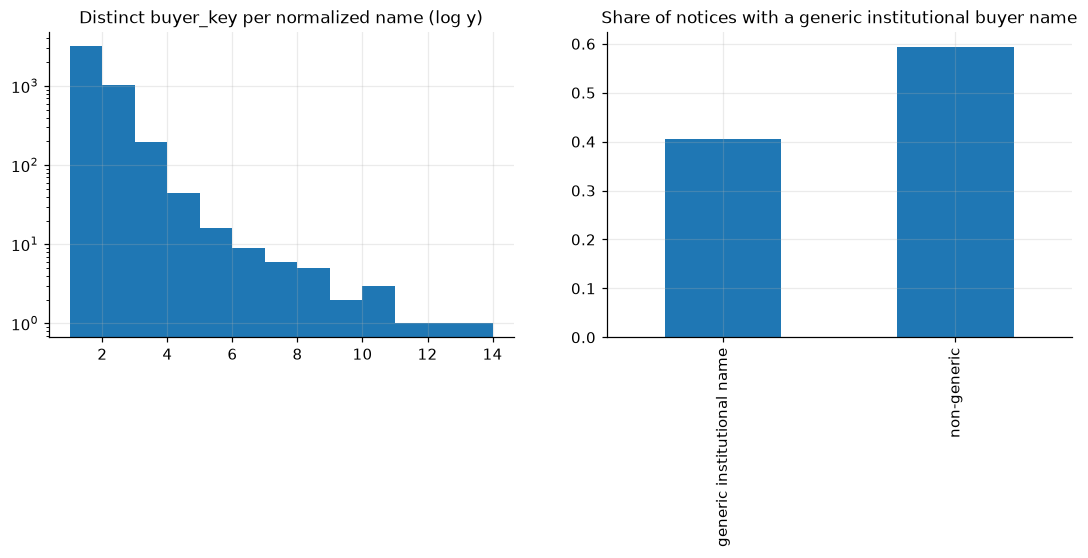

,n_normalized_names,n_fragmented_names,fragmentation_rate,max_keys_per_name
0,4492,1303,0.290071,13


Among fragmented names, 40.9% are generic-institutional (stoplist match); overall generic-name share of all notices: 40.6%.


In [8]:
frag_summary = fragmentation_summary(common)
frag_summary.to_csv(cfg.paths.reports_tables / "calib_buyer_name_fragmentation_summary.csv", index=False)

keys_per_name = common.groupby("buyer_name_normalized")["buyer_key"].nunique()
fragmented_names = keys_per_name[keys_per_name > 1].sort_values(ascending=False)

GENERIC_NAMES = list(cfg.pipeline.enrichment.alias_bridge.generic_names)
def is_generic_name(name):
    if not isinstance(name, str):
        return False
    return any(tok in name for tok in GENERIC_NAMES)

common["buyer_name_generic"] = common["buyer_name_normalized"].map(is_generic_name)
frag_names_df = fragmented_names.rename("n_distinct_keys").head(20).to_frame()
frag_names_df["is_generic"] = frag_names_df.index.map(is_generic_name)
frag_names_df.to_csv(cfg.paths.reports_tables / "calib_buyer_name_fragmentation_examples.csv")

generic_frag_rate = np.mean(list(fragmented_names.index.map(is_generic_name))) if len(fragmented_names) else float("nan")
overall_generic_rate = common["buyer_name_generic"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].hist(keys_per_name, bins=range(1, int(keys_per_name.max()) + 2))
axes[0].set_yscale("log")
axes[0].set_title("Distinct buyer_key per normalized name (log y)")
pd.Series({"generic institutional name": overall_generic_rate,
           "non-generic": 1 - overall_generic_rate}).plot(kind="bar", ax=axes[1])
axes[1].set_title("Share of notices with a generic institutional buyer name")
plt.show()
save_figure(fig, "calib_buyer_name_fragmentation", cfg)

display(frag_summary)
print(f"Among fragmented names, {generic_frag_rate:.1%} are generic-institutional (stoplist match); "
      f"overall generic-name share of all notices: {overall_generic_rate:.1%}.")

add_provenance("buyer_name_fragmentation_rate", "Share of normalized buyer names mapping to >1 buyer_key",
                "OBSERVABLE", round(float(frag_summary["fragmentation_rate"].iloc[0]), 4), "rate", "marginal",
                "data/interim/boamp_common_prepared.csv", "buyer_name_normalized,buyer_key",
                "src/boamp/data/identity_boamp.py::fragmentation_summary", n_total, "7",
                "calib_buyer_name_fragmentation_summary.csv",
                "A data-quality measure of BOAMP-native identity resolution, not a linkage-accuracy claim; "
                "generic institutional names (mairie, commune, ...) fragment for a different reason than "
                "genuine spelling/legal-form variants and are reported separately.")

## 8. CPV quality

Missingness and genericity (only the 2-digit division meaningful, pattern `XX000000`)
of the declared CPV code, marginal and conditional on year, schema, notice type,
department, buyer activity, and identifier source.

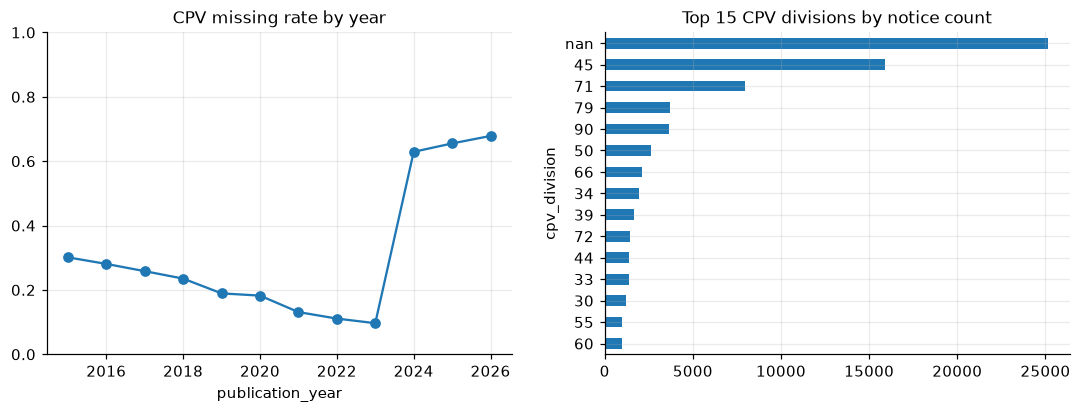

cpv_missing_rate                  0.296846
cpv_generic_rate_among_present    0.070635
dtype: float64

In [9]:
cpv_missing_rate = common["cpv_missing"].astype(bool).mean()
cpv_generic_rate_among_present = common.loc[~common["cpv_missing"].astype(bool), "cpv_generic_flag"].astype(bool).mean()

cpv_summary = pd.Series({
    "cpv_missing_rate": cpv_missing_rate,
    "cpv_generic_rate_among_present": cpv_generic_rate_among_present,
})
cpv_summary.to_csv(cfg.paths.reports_tables / "calib_cpv_quality_summary.csv")

CPV_DIMS = ["publication_year", "schema_family", "notice_type_normalized", "dept_primary",
            "buyer_activity_tier", "buyer_identifier_source"]
rows = []
for dim in CPV_DIMS:
    g = common.groupby(dim)
    tmp = pd.DataFrame({
        "missing_rate": g["cpv_missing"].apply(lambda s: s.astype(bool).mean()),
        "n": g.size(),
    })
    tmp["dim"] = dim
    tmp = tmp.reset_index().rename(columns={dim: "value"})
    rows.append(tmp)
cpv_missing_by_conditioning = pd.concat(rows, ignore_index=True)
cpv_missing_by_conditioning.to_csv(cfg.paths.reports_tables / "calib_cpv_missingness_by_conditioning.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
common.groupby("publication_year")["cpv_missing"].apply(lambda s: s.astype(bool).mean()).plot(ax=axes[0], marker="o")
axes[0].set_ylim(0, 1); axes[0].set_title("CPV missing rate by year")
cpv_division_coverage["n_notices"].sort_values(ascending=False).head(15).sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Top 15 CPV divisions by notice count")
plt.show()
save_figure(fig, "calib_cpv_quality_by_division_year", cfg)

display(cpv_summary)

add_provenance("cpv_missing_rate", "CPV code missing rate", "OBSERVABLE", round(float(cpv_missing_rate), 4),
                "rate", "marginal + by year/schema/notice_type/department/buyer_activity/identifier_source",
                "data/interim/boamp_common_prepared.csv", "cpv_missing,cpv_generic_flag",
                "src/boamp/data/prepare.py cpv cleaning; mean of boolean flags", n_total, "8",
                "calib_cpv_missingness_by_conditioning.csv",
                "cpv_clean requires exact 8-digit format; malformed/multi-code strings are treated as missing.")

## 9. Duration quality

Computes this notebook's **own** full-corpus duration-completeness/plausibility rate
from the raw extracted `duration_raw` field. This is *not* the pipeline's commonly-cited
"88% imputed" figure — that number is computed only over the pipeline's eligible source
population (`notice_type_normalized == APPEL_OFFRE & is_digital_scope`), a small,
scope-restricted subset. A separate, clearly-labeled panel below reproduces that
scope-conditioned view for comparison, so the two numbers are never conflated.

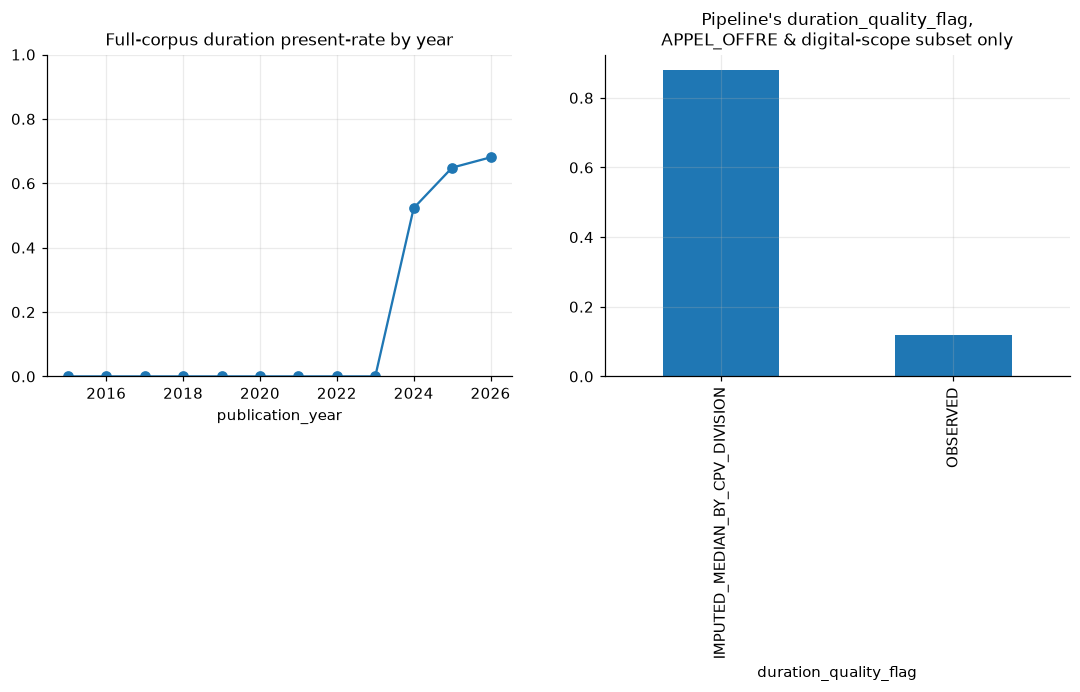

Full corpus: duration observed for 13.6% of notices (0.14% of all notices have an out-of-[1,120]-month value).
Pipeline's own eligible-source scope (n=3159): 12.0% OBSERVED, rest imputed/out-of-range.


In [10]:
duration_present_rate = common["duration_raw"].notna().mean()
in_range = common["duration_raw"].between(cfg.pipeline.duration.min_plausible_months,
                                           cfg.pipeline.duration.max_plausible_months)
duration_out_of_range_rate = (common["duration_raw"].notna() & ~in_range).mean()

duration_summary = pd.Series({
    "duration_present_rate_full_corpus": duration_present_rate,
    "duration_out_of_range_rate_full_corpus": duration_out_of_range_rate,
})
duration_summary.to_csv(cfg.paths.reports_tables / "calib_duration_quality_summary.csv")

DUR_DIMS = ["publication_year", "schema_family", "notice_type_normalized", "cpv_division", "buyer_activity_tier"]
rows = []
for dim in DUR_DIMS:
    g = common.groupby(dim)
    tmp = pd.DataFrame({"present_rate": g["duration_raw"].apply(lambda s: s.notna().mean()), "n": g.size()})
    tmp["dim"] = dim
    rows.append(tmp.reset_index().rename(columns={dim: "value"}))
duration_missingness_by_conditioning = pd.concat(rows, ignore_index=True)
duration_missingness_by_conditioning.to_csv(
    cfg.paths.reports_tables / "calib_duration_missingness_by_conditioning.csv", index=False)

oor_examples = common.loc[common["duration_raw"].notna() & ~in_range,
                           ["notice_id", "duration_raw", "cpv_division", "notice_type_normalized"]].head(30)
oor_examples.to_csv(cfg.paths.reports_tables / "calib_duration_out_of_range_examples.csv", index=False)

ao_mask = (common["notice_type_normalized"] == "APPEL_OFFRE") & common["is_digital_scope"]
pipeline_scope_flags = common.loc[ao_mask, "duration_quality_flag"].value_counts(normalize=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
common.groupby("publication_year")["duration_raw"].apply(lambda s: s.notna().mean()).plot(ax=axes[0], marker="o")
axes[0].set_ylim(0, 1); axes[0].set_title("Full-corpus duration present-rate by year")
pipeline_scope_flags.plot(kind="bar", ax=axes[1])
axes[1].set_title("Pipeline's duration_quality_flag,\nAPPEL_OFFRE & digital-scope subset only")
plt.show()
save_figure(fig, "calib_duration_quality_by_conditioning", cfg)

print(f"Full corpus: duration observed for {duration_present_rate:.1%} of notices "
      f"({duration_out_of_range_rate:.2%} of all notices have an out-of-[1,120]-month value).")
print(f"Pipeline's own eligible-source scope (n={ao_mask.sum()}): "
      f"{pipeline_scope_flags.get('OBSERVED', 0):.1%} OBSERVED, rest imputed/out-of-range.")

add_provenance("duration_present_rate_full_corpus", "Duration field present, full corpus",
                "OBSERVABLE", round(float(duration_present_rate), 4), "rate", "marginal + conditional",
                "data/interim/boamp_common_prepared.csv", "duration_raw",
                "notna mean, full corpus (not scope-filtered)", n_total, "9",
                "calib_duration_quality_summary.csv",
                "Distinct from the pipeline's 88%-imputed figure, which is computed only over the "
                "APPEL_OFFRE & digital-scope eligible-source subset, not the full corpus.")

## 10. Procurement-text characteristics

Length/token-count distributions of the cleaned contract object (`objet_clean`),
missingness, an independently-fitted top-n-gram profile (a fresh `CountVectorizer`,
*not* the linkage pipeline's fitted TF-IDF vectorizer), and an exact-duplicate-text rate
as a simple proxy for template/boilerplate language that increases candidate ambiguity.

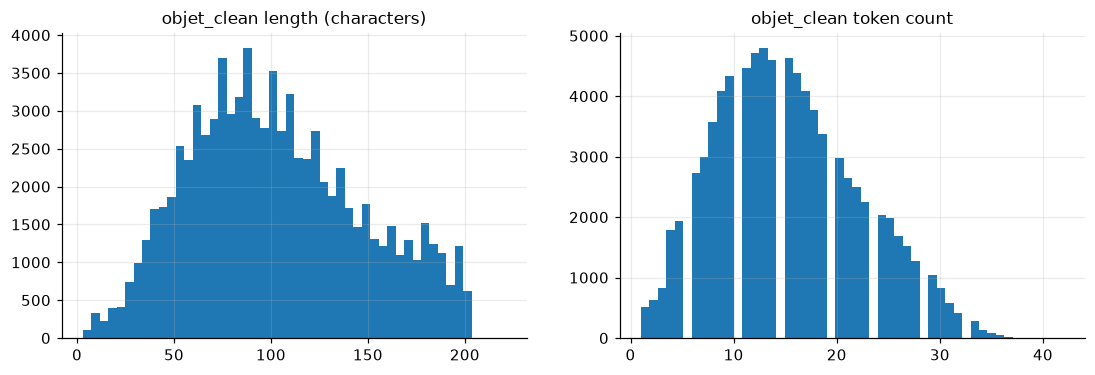

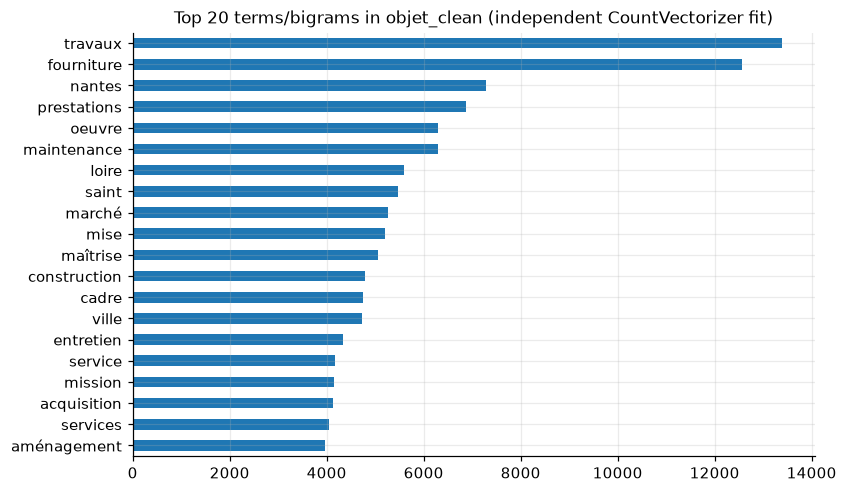

Text missing for 0.0% of notices. Exact-duplicate objet_clean rate among non-missing text: 51.4% (n=84,622) — a lower bound on template reuse.


In [11]:
text_missing_rate = common["objet_clean"].isna().mean()
text_len_stats = common["text_length"].describe()
token_stats = common["token_count"].describe()

txt = common["objet_clean"].dropna()
near_dup_rate = txt.duplicated(keep=False).mean()

from sklearn.feature_extraction.text import CountVectorizer
FR_STOPWORDS = ["de", "la", "le", "les", "des", "du", "et", "en", "pour", "un", "une",
                "à", "au", "aux", "d", "l", "dans", "sur", "avec", "par"]
vec = CountVectorizer(max_features=30, ngram_range=(1, 2), min_df=5, stop_words=FR_STOPWORDS)
X = vec.fit_transform(txt.values)
term_freqs = pd.Series(np.asarray(X.sum(axis=0)).ravel(), index=vec.get_feature_names_out()) \
               .sort_values(ascending=False)

text_summary = pd.Series({
    "text_missing_rate": text_missing_rate,
    "near_duplicate_text_rate": near_dup_rate,
    "median_text_length_chars": text_len_stats["50%"],
    "median_token_count": token_stats["50%"],
})
text_summary.to_csv(cfg.paths.reports_tables / "calib_text_characteristics_summary.csv")
term_freqs.rename("frequency").to_csv(cfg.paths.reports_tables / "calib_text_top_ngrams.csv")
pd.Series({"near_duplicate_rate": near_dup_rate, "n_non_missing": len(txt)}) \
  .to_csv(cfg.paths.reports_tables / "calib_text_near_duplicate_rate.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].hist(common["text_length"].dropna(), bins=50)
axes[0].set_title("objet_clean length (characters)")
axes[1].hist(common["token_count"].dropna(), bins=50)
axes[1].set_title("objet_clean token count")
plt.show()
save_figure(fig, "calib_text_length_token_distributions", cfg)

fig, ax = plt.subplots(figsize=(8, 5))
term_freqs.head(20).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 20 terms/bigrams in objet_clean (independent CountVectorizer fit)")
plt.show()
save_figure(fig, "calib_text_top_ngrams", cfg)

print(f"Text missing for {text_missing_rate:.1%} of notices. Exact-duplicate objet_clean rate "
      f"among non-missing text: {near_dup_rate:.1%} (n={len(txt):,}) — a lower bound on template reuse.")

add_provenance("text_near_duplicate_rate", "Exact-duplicate objet_clean rate", "OBSERVABLE",
                round(float(near_dup_rate), 4), "rate", "among non-missing text",
                "data/interim/boamp_common_prepared.csv", "objet_clean",
                "duplicated(keep=False).mean()", len(txt), "10",
                "calib_text_near_duplicate_rate.csv",
                "Exact-string duplication only; near-duplicate detection via fuzzy/semantic similarity "
                "would find a higher rate. This is a lower bound on text-based candidate ambiguity.")

## 11. Missingness dependency structure

Six binary data-quality flags, chosen to match exactly the dimensions the calibration
brief called out: missing SIRET/SIREN, buyer-name variation (proxied by reliance on the
NAME_FALLBACK identity mechanism), missing-or-generic CPV, missing duration, weak/missing
text, and unresolved award links (the ATTRIBUTION reverse-lookup in `prepare_common`
failing to find a start date, i.e. `start_date_source == PUBLICATION_DATE_FALLBACK` —
itself a *shared-prep* artifact, not a linkage output). Pairwise co-occurrence and a
phi-coefficient correlation matrix (Pearson correlation on 0/1 flags) are computed on the
full corpus; note `siret_or_siren_missing` and `name_fallback` are *definitionally*
linked (NAME_FALLBACK is only assigned when both are absent — see `identity_boamp.py`),
so their correlation is a construction artifact, not an empirical finding.

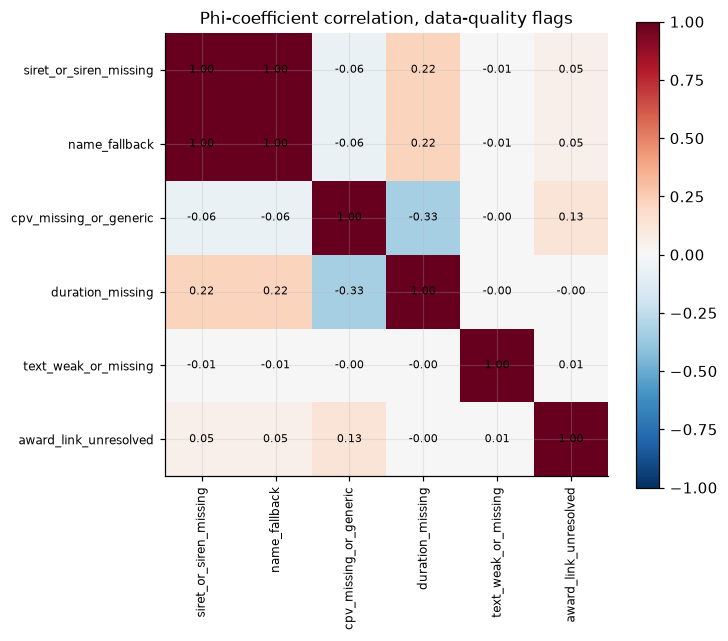

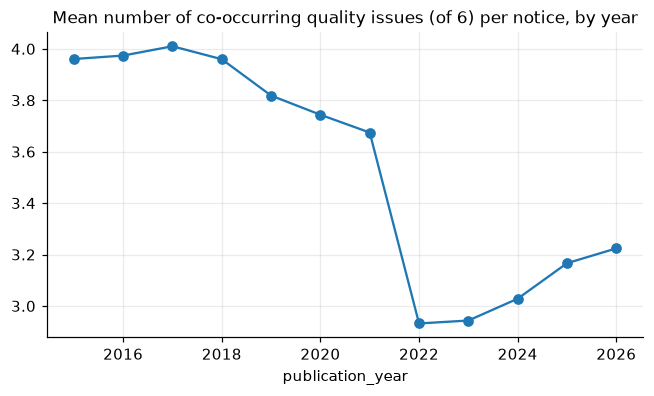

siret_or_siren_missing    0.727757
name_fallback             0.727757
cpv_missing_or_generic    0.346513
duration_missing          0.863548
text_weak_or_missing      0.104463
award_link_unresolved     0.759687
dtype: float64

,siret_or_siren_missing,name_fallback,cpv_missing_or_generic,duration_missing,text_weak_or_missing,award_link_unresolved
siret_or_siren_missing,1.00,1.00,-0.06,0.22,-0.01,0.05
name_fallback,1.00,1.00,-0.06,0.22,-0.01,0.05
cpv_missing_or_generic,-0.06,-0.06,1.00,-0.33,-0.00,0.13
duration_missing,0.22,0.22,-0.33,1.00,-0.00,-0.00
text_weak_or_missing,-0.01,-0.01,-0.00,-0.00,1.00,0.01
award_link_unresolved,0.05,0.05,0.13,-0.00,0.01,1.00


In [12]:
text_len_p10 = common["text_length"].quantile(0.10)
flags = pd.DataFrame({
    "siret_or_siren_missing": common["buyer_siret_clean"].isna() & common["buyer_siren_clean"].isna(),
    "name_fallback": common["buyer_key_type"] == "NAME_FALLBACK",
    "cpv_missing_or_generic": common["cpv_missing"].astype(bool) | common["cpv_generic_flag"].astype(bool),
    "duration_missing": common["duration_raw"].isna(),
    "text_weak_or_missing": common["objet_clean"].isna() | (common["text_length"] <= text_len_p10),
    "award_link_unresolved": common["start_date_source"] == "PUBLICATION_DATE_FALLBACK",
}, index=common.index)
flags_int = flags.astype(int)

marginal_flag_rates = flags_int.mean()
phi_matrix = flags_int.corr()

marginal_flag_rates.to_csv(cfg.paths.reports_tables / "calib_missingness_joint_matrix.csv")
phi_matrix.to_csv(cfg.paths.reports_tables / "calib_missingness_joint_matrix.csv", mode="a")

joint_dims = ["publication_year", "schema_family", "dept_primary", "cpv_division", "buyer_activity_tier"]
rows = []
flag_names = list(flags.columns)
for dim in joint_dims:
    g = pd.concat([common[dim], flags_int], axis=1).groupby(dim)
    for a_i, a in enumerate(flag_names):
        for b in flag_names[a_i + 1:]:
            joint = g.apply(lambda d: (d[a] & d[b]).mean() if len(d) else np.nan, include_groups=False)
            for value, rate in joint.items():
                rows.append({"stratum_dim": dim, "stratum_value": value, "flag_a": a, "flag_b": b,
                             "joint_rate": rate, "n": g.size().get(value, 0)})
cooccurrence_by_conditioning = pd.DataFrame(rows)
cooccurrence_by_conditioning.to_csv(
    cfg.paths.reports_tables / "calib_missingness_cooccurrence_by_conditioning.csv", index=False)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(phi_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(flag_names))); ax.set_xticklabels(flag_names, rotation=90, fontsize=8)
ax.set_yticks(range(len(flag_names))); ax.set_yticklabels(flag_names, fontsize=8)
for i in range(len(flag_names)):
    for j in range(len(flag_names)):
        ax.text(j, i, f"{phi_matrix.values[i, j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("Phi-coefficient correlation, data-quality flags")
fig.colorbar(im, ax=ax)
plt.show()
save_figure(fig, "calib_missingness_correlation_heatmap", cfg)

issues_per_notice_by_year = pd.concat([common["publication_year"], flags_int.sum(axis=1).rename("n_issues")], axis=1) \
                               .groupby("publication_year")["n_issues"].mean()
fig, ax = plt.subplots(figsize=(7, 3.6))
issues_per_notice_by_year.plot(ax=ax, marker="o")
ax.set_title("Mean number of co-occurring quality issues (of 6) per notice, by year")
plt.show()
save_figure(fig, "calib_missingness_cooccurrence_by_year", cfg)

display(marginal_flag_rates)
display(phi_matrix.round(2))

add_provenance("missingness_phi_matrix", "Phi-coefficient correlation among 6 quality flags",
                "OBSERVABLE", "see table", "correlation (-1..1)", "marginal + by year/schema/dept/cpv/buyer_activity",
                "data/interim/boamp_common_prepared.csv",
                "buyer_siret_clean,buyer_siren_clean,buyer_key_type,cpv_missing,cpv_generic_flag,"
                "duration_raw,objet_clean,text_length,start_date_source",
                "Pearson correlation on binary 0/1 flags (= phi coefficient)", n_total, "11",
                "calib_missingness_correlation_heatmap.png",
                "siret_or_siren_missing and name_fallback are definitionally linked by the buyer_key "
                "construction ladder (identity_boamp.py), not an independent empirical association.")

## 12. Scope & eligibility as a conditioning variable

The linkage pipeline restricts to a digital/ICT-scope, Pays-de-la-Loire-scope eligible
source population. Per the calibration brief, scope is treated here as one more
conditioning dimension on the full corpus, not a pre-filter applied before analysis.

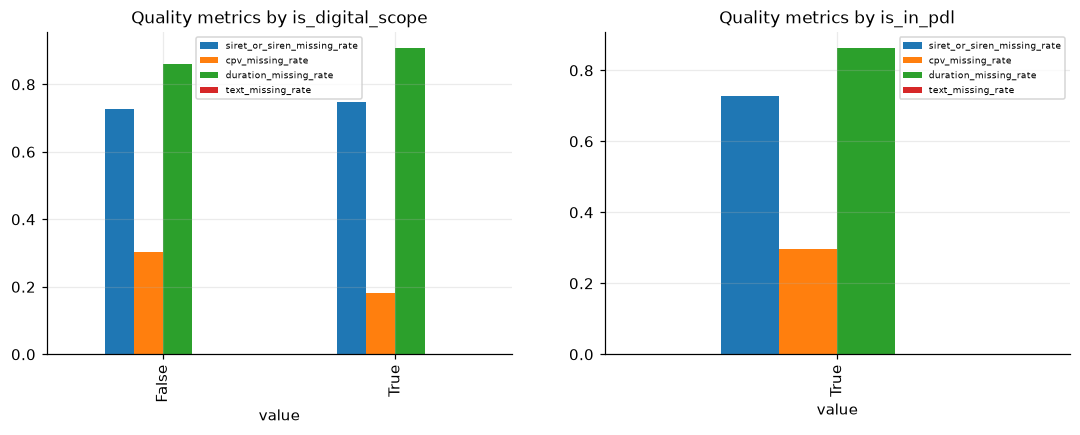

,scope_dim,value,n,siret_or_siren_missing_rate,cpv_missing_rate,duration_missing_rate,text_missing_rate
0,is_digital_scope,False,79793,0.726492,0.303874,0.860840,0.000013
1,is_digital_scope,True,4830,0.748654,0.180745,0.908282,0.000000
2,is_in_pdl,True,84623,0.727757,0.296846,0.863548,0.000012


In [13]:
scope_dims = pd.DataFrame({
    "is_digital_scope": common["is_digital_scope"],
    "is_in_pdl": common["is_in_pdl"],
})
scope_crosstab_rows = []
for label, mask_col in [("is_digital_scope", "is_digital_scope"), ("is_in_pdl", "is_in_pdl")]:
    for val, sub in common.groupby(mask_col):
        scope_crosstab_rows.append({
            "scope_dim": label, "value": val, "n": len(sub),
            "siret_or_siren_missing_rate": (sub["buyer_siret_clean"].isna() & sub["buyer_siren_clean"].isna()).mean(),
            "cpv_missing_rate": sub["cpv_missing"].astype(bool).mean(),
            "duration_missing_rate": sub["duration_raw"].isna().mean(),
            "text_missing_rate": sub["objet_clean"].isna().mean(),
        })
scope_conditioning_crosstab = pd.DataFrame(scope_crosstab_rows)
scope_conditioning_crosstab.to_csv(cfg.paths.reports_tables / "calib_scope_conditioning_crosstab.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
sub = scope_conditioning_crosstab[scope_conditioning_crosstab["scope_dim"] == "is_digital_scope"] \
        .set_index("value")[["siret_or_siren_missing_rate", "cpv_missing_rate", "duration_missing_rate", "text_missing_rate"]]
sub.plot(kind="bar", ax=axes[0]); axes[0].set_title("Quality metrics by is_digital_scope"); axes[0].legend(fontsize=6)
sub2 = scope_conditioning_crosstab[scope_conditioning_crosstab["scope_dim"] == "is_in_pdl"] \
        .set_index("value")[["siret_or_siren_missing_rate", "cpv_missing_rate", "duration_missing_rate", "text_missing_rate"]]
sub2.plot(kind="bar", ax=axes[1]); axes[1].set_title("Quality metrics by is_in_pdl"); axes[1].legend(fontsize=6)
plt.show()
save_figure(fig, "calib_scope_conditioning_overview", cfg)

display(scope_conditioning_crosstab)

add_provenance("scope_conditioning_crosstab", "Quality metrics split by digital-scope / PDL-scope eligibility",
                "OBSERVABLE", "see table", "rate", "by is_digital_scope, is_in_pdl",
                "data/interim/boamp_common_prepared.csv", "is_digital_scope,is_in_pdl",
                "groupby, mean of quality flags", n_total, "12",
                "calib_scope_conditioning_crosstab.csv",
                "is_digital_scope combines a CPV-division rule with a French keyword search over "
                "objet_normalized (config/pipeline.yaml scope block); it is a scope-tagging heuristic.")

## 13. Candidate-environment complexity (independent window sweep)

Recomputes candidate-set size directly from `publication_date` and `buyer_key` — **not**
from `estimated_end_date`/duration and **not** from `candidate_pairs.csv` — across a swept
set of window widths. This deliberately avoids the pipeline's frozen six-month convention
(derived from *its own* rank-1 score distribution) and instead asks a model-free question:
for a given buyer-blocking key, how many other same-buyer notices fall within ±W months of
any given notice's publication date? The result is a direct input to a synthetic
generator's candidate-density scenario grid.

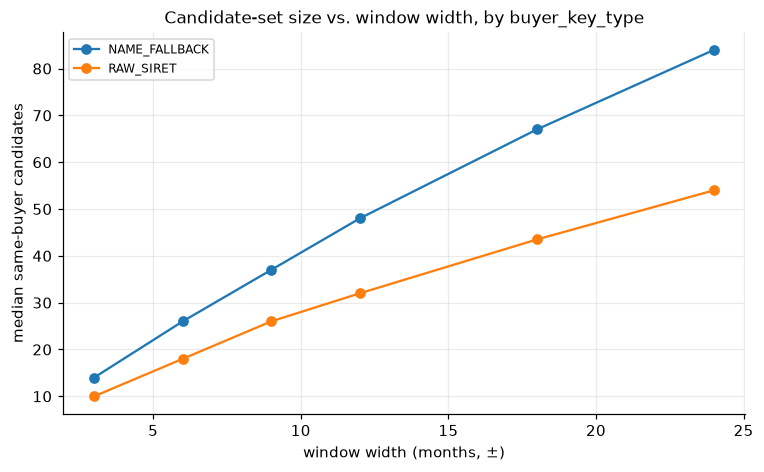

,window_months,buyer_key_type,mean,median,p90,pct_zero_candidates,n
0,3,NAME_FALLBACK,29.545344,14.0,79.0,0.083868,61585
1,3,RAW_SIRET,24.918917,10.0,69.0,0.118891,23038
2,6,NAME_FALLBACK,57.011220,26.0,150.0,0.051522,61585
3,6,RAW_SIRET,47.444917,18.0,135.0,0.065848,23038
4,9,NAME_FALLBACK,83.214419,37.0,214.0,0.041926,61585
5,9,RAW_SIRET,68.040542,26.0,197.0,0.050829,23038
6,12,NAME_FALLBACK,108.869432,48.0,281.0,0.036535,61585
7,12,RAW_SIRET,87.338137,32.0,252.0,0.043407,23038
8,18,NAME_FALLBACK,155.095656,67.0,397.0,0.031485,61585
9,18,RAW_SIRET,120.139682,43.5,356.0,0.037156,23038


In [14]:
def candidate_window_counts(df, buyer_col, date_col, window_months):
    window_days = window_months * cfg.pipeline.run.month_days
    out = pd.Series(0, index=df.index, dtype=int)
    sub = df.dropna(subset=[buyer_col])
    for _, grp in sub.groupby(buyer_col, sort=False):
        order = np.argsort(grp[date_col].values)
        dates_sorted = grp[date_col].values[order]
        days = (dates_sorted - dates_sorted.min()).astype("timedelta64[D]").astype(float)
        lo = np.searchsorted(days, days - window_days, side="left")
        hi = np.searchsorted(days, days + window_days, side="right")
        out.loc[grp.index[order]] = hi - lo - 1
    return out

WINDOWS = [3, 6, 9, 12, 18, 24]
window_summary_rows = []
for W in WINDOWS:
    counts_w = candidate_window_counts(common, "buyer_key", "publication_date", W)
    for tier, sub_idx in common.groupby("buyer_key_type").groups.items():
        c = counts_w.loc[counts_w.index.intersection(sub_idx)]
        window_summary_rows.append({
            "window_months": W, "buyer_key_type": tier, "mean": c.mean(), "median": c.median(),
            "p90": c.quantile(0.9), "pct_zero_candidates": (c == 0).mean(), "n": len(c),
        })
candidate_env_by_window = pd.DataFrame(window_summary_rows)
candidate_env_by_window.to_csv(cfg.paths.reports_tables / "calib_candidate_environment_complexity_by_window.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
for tier, sub in candidate_env_by_window.groupby("buyer_key_type"):
    ax.plot(sub["window_months"], sub["median"], marker="o", label=tier)
ax.set_xlabel("window width (months, ±)"); ax.set_ylabel("median same-buyer candidates")
ax.set_title("Candidate-set size vs. window width, by buyer_key_type")
ax.legend(fontsize=8)
plt.show()
save_figure(fig, "calib_candidate_environment_window_sweep", cfg)

display(candidate_env_by_window)

add_provenance("candidate_env_window_sweep", "Same-buyer candidate-set size vs window width",
                "OBSERVABLE", "see table", "count", "by window_months x buyer_key_type",
                "data/interim/boamp_common_prepared.csv", "buyer_key,publication_date,buyer_key_type",
                "searchsorted-based sliding window count per buyer_key group", n_total, "13",
                "calib_candidate_environment_complexity_by_window.csv",
                "Publication-date-based, not estimated-end-date-based; independent of the pipeline's "
                "6-month convention. NAME_FALLBACK buyer_key aggregates distinct real entities, inflating "
                "candidate density for that stratum specifically.")

## 14. Unidentified parameters & required scenario knobs

The parameters below cannot be estimated from any BOAMP output examined in this repo —
there are zero completed manual-validation labels anywhere (`docs/methodology.md` §9), so
nothing establishes ground-truth renewal/linkage outcomes. A synthetic benchmark generator
should expose each of these as a **swept scenario parameter** (a grid or range), not a
single calibrated point estimate.

In [15]:
unidentified_params = pd.DataFrame([
    {"parameter_name": "true_recurrence_prevalence",
     "why_unidentified": "No verified legal-renewal field exists in BOAMP; the pipeline's own event rate "
                         "(19.6%/26.8%) is itself the output of an unvalidated scoring+threshold procedure, "
                         "not a measurement of real renewal behaviour.",
     "proposed_scenario_range": "e.g. sweep true recurrence prevalence in {10%, 25%, 40%, 60%}",
     "justification_or_none": "no empirical anchor; range chosen to bracket the pipeline's own uncalibrated estimates"},
    {"parameter_name": "true_linkage_precision_recall",
     "why_unidentified": "Zero completed manual-validation labels exist; Fellegi-Sunter EM estimates in "
                         "03_analysis are explicitly model-based, not ground-truth-validated.",
     "proposed_scenario_range": "sweep precision/recall of the *injected* synthetic linker across a grid, "
                                 "e.g. precision in {0.6,0.75,0.9}, recall in {0.5,0.7,0.9}",
     "justification_or_none": "no empirical anchor"},
    {"parameter_name": "true_buyer_entity_resolution_rate",
     "why_unidentified": "No registry cross-validation of BOAMP-native buyer identity exists in this repo; "
                         "the Layer 2 external SIREN join covers only 2024-2026 and the alias bridge is an "
                         "unvalidated heuristic.",
     "proposed_scenario_range": "sweep the fraction of buyer-name variants correctly resolved to one entity, "
                                 "e.g. {50%, 70%, 90%}",
     "justification_or_none": "no empirical anchor; range informed by observed fragmentation_rate as a floor, "
                               "see calib_buyer_name_fragmentation_summary.csv"},
    {"parameter_name": "true_candidate_ambiguity_resolution",
     "why_unidentified": "Which candidate among several plausible same-buyer notices is the *correct* renewal "
                         "is never verified; §15's rank-1 selection is a modelling choice, not ground truth.",
     "proposed_scenario_range": "vary the number of plausible-but-wrong candidates per true link, "
                                 "e.g. {0, 1-2, 3-5, 6+}, informed by §13's window-sweep candidate-density numbers",
     "justification_or_none": "partially anchored by §13 (candidate density is observable); which candidate is correct is not"},
    {"parameter_name": "true_text_corruption_process",
     "why_unidentified": "No ground truth exists for how procurement text varies between a true renewal pair "
                         "vs. an unrelated notice; §10's near-duplicate rate only measures exact repetition.",
     "proposed_scenario_range": "sweep text-similarity degradation severity for true-pair synthetic text, "
                                 "e.g. cosine similarity target ranges {0.3-0.5, 0.5-0.7, 0.7-0.9}",
     "justification_or_none": "no empirical anchor"},
])
unidentified_params.to_csv(cfg.paths.reports_tables / "calib_unidentified_parameters_scenarios.csv", index=False)
display(unidentified_params)

for _, r in unidentified_params.iterrows():
    add_provenance(r["parameter_name"], r["parameter_name"].replace("_", " "), "UNIDENTIFIED",
                    r["proposed_scenario_range"], "n/a", "n/a", "n/a (no BOAMP source establishes this)",
                    "n/a", "analyst judgment / literature-free", 0, "14",
                    "calib_unidentified_parameters_scenarios.csv", r["why_unidentified"])

,parameter_name,why_unidentified,proposed_scenario_range,justification_or_none
0,true_recurrence_prevalence,No verified legal-renewal field exists in BOAM...,"e.g. sweep true recurrence prevalence in {10%,...",no empirical anchor; range chosen to bracket t...
1,true_linkage_precision_recall,Zero completed manual-validation labels exist;...,sweep precision/recall of the *injected* synth...,no empirical anchor
2,true_buyer_entity_resolution_rate,No registry cross-validation of BOAMP-native b...,sweep the fraction of buyer-name variants corr...,no empirical anchor; range informed by observe...
3,true_candidate_ambiguity_resolution,Which candidate among several plausible same-b...,vary the number of plausible-but-wrong candida...,partially anchored by §13 (candidate density i...
4,true_text_corruption_process,No ground truth exists for how procurement tex...,sweep text-similarity degradation severity for...,no empirical anchor


## 15. [WALLED OFF — SILVER-STANDARD TIER ONLY] Error co-occurrence & score diagnostics from accepted links

**This is the only section in the notebook that reads Layer 1/Layer 2 linkage outputs.**
Every statistic below is conditional on the pipeline's own threshold-based acceptance
decision — it describes "what accepted links look like", not an unconditional error rate,
and must not be used to estimate true recurrence prevalence or true linkage accuracy
(see §14). All figures here carry an explicit tier badge.

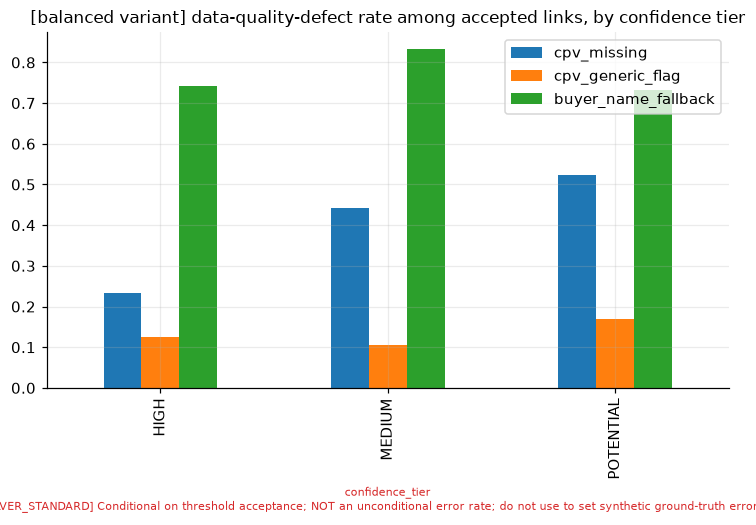

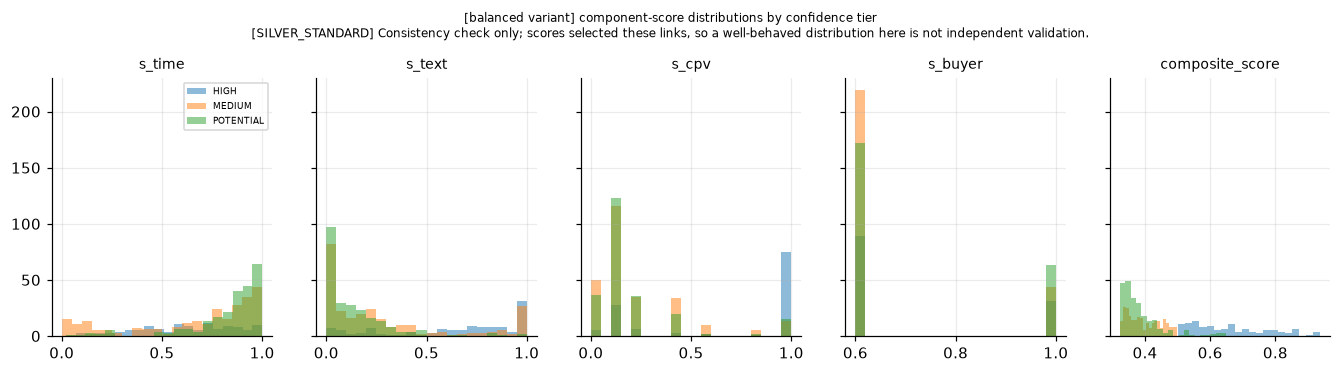

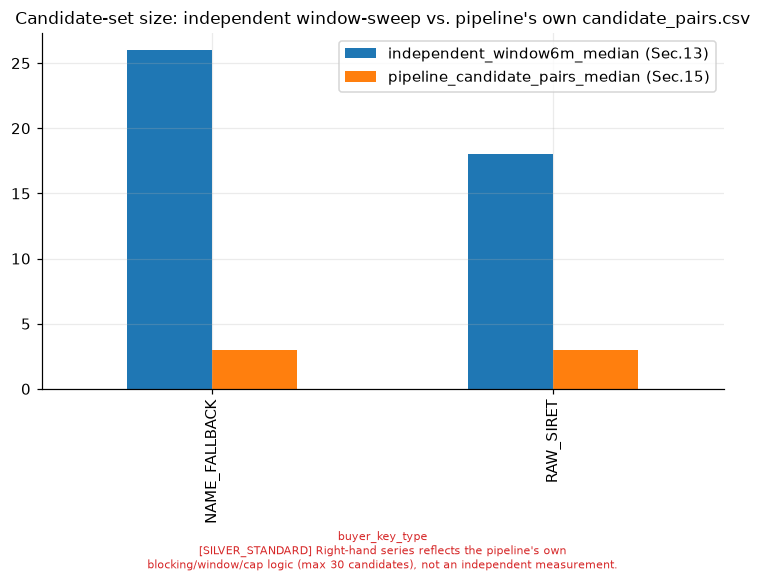

Alias bridge: 3159 buyer-identity propagations; 1002 unresolved native-vs-external SIREN conflicts flagged (never auto-resolved).


cpv_missing  cpv_generic_flag  buyer_name_fallback
variant  confidence_tier                                                    
balanced HIGH                0.233333          0.125000             0.741667
         MEDIUM              0.441065          0.106464             0.832700
         POTENTIAL           0.523404          0.170213             0.731915
broad    HIGH                0.233333          0.125000             0.741667
         MEDIUM              0.381176          0.117647             0.858824
         POTENTIAL           0.452880          0.159686             0.787958
strict   HIGH                0.233333          0.125000             0.741667
         MEDIUM              0.441667          0.100000             0.858333
         POTENTIAL           0.434783          0.173913             0.695652

In [16]:
D1, D2 = cfg.paths.processed_boamp_only, cfg.paths.processed_enriched
l1_pairs = pd.read_csv(D1 / "boamp_only_candidate_pairs.csv")
l1_links_balanced = pd.read_csv(D1 / "boamp_only_links_balanced.csv")
l1_links_broad = pd.read_csv(D1 / "boamp_only_links_broad.csv")
l1_links_strict = pd.read_csv(D1 / "boamp_only_links_strict.csv")
l1_links_balanced["variant"] = "balanced"; l1_links_broad["variant"] = "broad"; l1_links_strict["variant"] = "strict"
l1_links_all = pd.concat([l1_links_broad, l1_links_balanced, l1_links_strict], ignore_index=True)

alias_bridge = pd.read_csv(D2 / "alias_bridge.csv")
enrichment_conflicts = pd.read_csv(D2 / "enrichment_conflicts.csv")

# --- error co-occurrence among accepted links, by confidence tier ---
issue_cols = ["cpv_missing", "cpv_generic_flag"]
l1_links_all["buyer_name_fallback"] = l1_links_all["buyer_key_type"] == "NAME_FALLBACK"
error_cooccurrence_by_tier = l1_links_all.groupby(["variant", "confidence_tier"])[
    issue_cols + ["buyer_name_fallback"]].mean()
error_cooccurrence_by_tier.to_csv(cfg.paths.reports_tables / "calib_silver_error_cooccurrence_by_tier.csv")

# --- component-score distributions by confidence tier ---
score_cols = ["s_time", "s_text", "s_cpv", "s_buyer", "composite_score"]
score_summary_by_tier = l1_links_all.groupby(["variant", "confidence_tier"])[score_cols].agg(["mean", "median", "std"])
score_summary_by_tier.to_csv(cfg.paths.reports_tables / "calib_silver_score_component_summary_by_tier.csv")

# --- candidate ambiguity from candidate_pairs.csv (rank-1 rows), vs Section 13 ---
r1 = l1_pairs[l1_pairs["candidate_rank"] == 1]
candidate_ambiguity_by_quality = r1.groupby(["buyer_key_type", "cpv_missing"])[
    ["n_candidates_for_source", "top1_top2_margin"]].median()
candidate_ambiguity_by_quality.to_csv(cfg.paths.reports_tables / "calib_silver_candidate_ambiguity_by_quality.csv")

fig, ax = plt.subplots(figsize=(8, 4.2))
error_cooccurrence_by_tier.loc["balanced"].plot(kind="bar", ax=ax)
ax.set_title("[balanced variant] data-quality-defect rate among accepted links, by confidence tier")
add_tier_caveat_to_xlabel(ax, "SILVER_STANDARD",
                "Conditional on threshold acceptance; NOT an unconditional error rate; do not use to set synthetic ground-truth error rates.")
plt.show()
save_figure(fig, "calib_silver_error_cooccurrence", cfg)

fig, axes = plt.subplots(1, len(score_cols), figsize=(3 * len(score_cols), 3.4), sharey=True)
for ax, col in zip(axes, score_cols):
    for tier, sub in l1_links_all[l1_links_all["variant"] == "balanced"].groupby("confidence_tier"):
        ax.hist(sub[col], bins=20, alpha=0.5, label=tier)
    ax.set_title(col, fontsize=9)
axes[0].legend(fontsize=6)
fig.suptitle("[balanced variant] component-score distributions by confidence tier\n"
             "[SILVER_STANDARD] Consistency check only; scores selected these links, so a well-behaved "
             "distribution here is not independent validation.", fontsize=8, color="black")
fig.subplots_adjust(top=0.80)
plt.show()
save_figure(fig, "calib_silver_score_distributions_by_tier", cfg)

fig, ax = plt.subplots(figsize=(8, 4.2))
r1_median_by_W = candidate_env_by_window[candidate_env_by_window["window_months"] == 6] \
    .set_index("buyer_key_type")["median"]
pipeline_median = r1.groupby("buyer_key_type")["n_candidates_for_source"].median()
compare = pd.DataFrame({"independent_window6m_median (Sec.13)": r1_median_by_W,
                         "pipeline_candidate_pairs_median (Sec.15)": pipeline_median}).dropna()
compare.plot(kind="bar", ax=ax)
ax.set_title("Candidate-set size: independent window-sweep vs. pipeline's own candidate_pairs.csv")
add_tier_caveat_to_xlabel(ax, "SILVER_STANDARD",
                "Right-hand series reflects the pipeline's own\nblocking/window/cap logic (max 30 candidates), not an independent measurement.")
plt.show()
save_figure(fig, "calib_silver_candidate_ambiguity", cfg)

print(f"Alias bridge: {len(alias_bridge)} buyer-identity propagations; {len(enrichment_conflicts)} unresolved "
      f"native-vs-external SIREN conflicts flagged (never auto-resolved).")
display(error_cooccurrence_by_tier)

add_provenance("silver_error_cooccurrence_by_tier", "Data-quality-defect co-occurrence among accepted links",
                "SILVER_STANDARD", "see table", "rate", "by threshold variant x confidence_tier",
                "data/processed/boamp_only/boamp_only_links_{broad,balanced,strict}.csv",
                "cpv_missing,cpv_generic_flag,buyer_key_type,confidence_tier",
                "groupby variant+confidence_tier, mean of flags", len(l1_links_all), "15",
                "calib_silver_error_cooccurrence_by_tier.csv",
                "Conditional on the pipeline's own threshold-based acceptance; selection bias by construction; "
                "must not be used as an unconditional error rate or to estimate true linkage accuracy.")
add_provenance("silver_candidate_ambiguity", "Candidate-set size/margin at rank-1, by identifier/CPV quality",
                "SILVER_STANDARD", "see table", "count / margin", "by buyer_key_type x cpv_missing",
                "data/processed/boamp_only/boamp_only_candidate_pairs.csv",
                "n_candidates_for_source,top1_top2_margin,buyer_key_type,cpv_missing",
                "groupby median", len(r1), "15",
                "calib_silver_candidate_ambiguity_by_quality.csv",
                "Reflects the pipeline's own 6-month window and 30-candidate cap (config/pipeline.yaml); "
                "compare against Section 13's independent window sweep, do not treat as the 'true' candidate density.")

## 16. Parameter-provenance inventory compilation

Every statistic produced above was appended to `provenance_rows` as it was computed.
This is the enforcement mechanism for the tier separation the calibration brief demands:
every row is tagged OBSERVABLE / SILVER_STANDARD / UNIDENTIFIED and carries a mandatory,
non-empty caveat.

In [17]:
provenance_inventory = pd.DataFrame(provenance_rows)
assert (provenance_inventory["caveat"].str.len() > 0).all(), "every provenance row must carry a caveat"
assert set(provenance_inventory["tier"]) <= {"OBSERVABLE", "SILVER_STANDARD", "UNIDENTIFIED"}

silver_rows = provenance_inventory[provenance_inventory["tier"] == "SILVER_STANDARD"]
assert silver_rows["source_file"].str.contains("data/processed/").all(), \
    "every SILVER_STANDARD row must cite a data/processed/ source"

provenance_inventory.to_csv(cfg.paths.reports_tables / "calib_parameter_provenance_inventory.csv", index=False)
print(f"Provenance inventory: {len(provenance_inventory)} rows "
      f"({provenance_inventory['tier'].value_counts().to_dict()}).")
display(provenance_inventory[["parameter_id", "tier", "notebook_section", "caveat"]])

Provenance inventory: 22 rows ({'OBSERVABLE': 15, 'UNIDENTIFIED': 5, 'SILVER_STANDARD': 2}).


,parameter_id,tier,notebook_section,caveat
0,n_total_notices,OBSERVABLE,1,"Full corpus, all sectors, all notice types, no..."
1,dept_coverage,OBSERVABLE,2,code_departement can list several departments ...
2,notice_type_by_year,OBSERVABLE,2,notice_type_normalized collapses rare types to...
3,field_completeness_marginal,OBSERVABLE,3,Includes both raw and derived columns.
4,key_field_completeness_by_year,OBSERVABLE,3,"Trend, not a validated forecast."
5,schema_transition_shift,OBSERVABLE,4,schema_family is detected heuristically from t...
6,buyer_activity_gini,OBSERVABLE,5,buyer_key is BOAMP-native identity (SIRET/SIRE...
7,identifier_source_marginal,OBSERVABLE,6,RAW_SIRET_FIELD/RAW_SIREN_FIELD/DERIVED_FROM_S...
8,buyer_name_fragmentation_rate,OBSERVABLE,7,A data-quality measure of BOAMP-native identit...
9,cpv_missing_rate,OBSERVABLE,8,cpv_clean requires exact 8-digit format; malfo...


## 17. Final report generation

Assembles a markdown report summarizing what the synthetic generator should reproduce,
what remains uncertain, and which pipeline outputs must never be used to construct
synthetic ground truth.

In [18]:
report_lines = []
def rline(s=""):
    report_lines.append(s)

rline("# Synthetic linkage benchmark: calibration report")
rline()
rline(f"Generated from `notebooks/04_synthetic_benchmark_calibration.ipynb`, "
      f"corpus: {n_total:,} BOAMP notices, {year_min}-{year_max}, Pays de la Loire "
      f"(departments {', '.join(cfg.pipeline.scope.pdl_departments)}).")
rline()
rline("## 1. Purpose & scope")
rline("This report summarizes the real-corpus properties a synthetic BOAMP-like linkage "
      "benchmark generator should reproduce, and draws a hard line around what may and "
      "may not be used to construct synthetic ground truth.")
rline()
rline("## 2. Tiering framework")
rline("- **OBSERVABLE** — measured directly from raw fields or the shared, layer-neutral "
      "preparation logic on the full corpus.")
rline("- **SILVER_STANDARD** — visible only through Layer 1/Layer 2 accepted links "
      "(Section 15 of the notebook only); always conditional on threshold acceptance, "
      "never an unconditional error/accuracy rate.")
rline("- **UNIDENTIFIED** — cannot be estimated from any BOAMP output in this repo; must "
      "be exposed as a swept scenario parameter in the generator, not calibrated to a point.")
rline()
rline("## 3. Population structure")
rline(f"- {n_total:,} notices, years {year_min}-{year_max}.")
rline(f"- Schema transition (LEGACY -> EFORMS) around the ~Oct 2023 eForms mandate; "
      f"see `calib_schema_transition_shift.csv` for the field-completeness shift it caused.")
rline(f"- {n_buyers:,} distinct buyer_key values; activity Gini={gini:.3f}, "
      f"top-1 buyer share={buyer_counts.iloc[0] / buyer_counts.sum():.1%}.")
rline()
rline("## 4. Observable distributions the synthetic generator should reproduce")
obs_rows = provenance_inventory[provenance_inventory["tier"] == "OBSERVABLE"]
for _, r in obs_rows.iterrows():
    rline(f"- **{r['parameter_name']}** ({r['notebook_section']}): `{r['value_or_range']}` "
          f"[{r['stratification']}] -> `{r['figure_or_table_ref']}`. {r['caveat']}")
rline()
rline("## 5. Silver-standard-only observations (Section 15)")
rline("These describe accepted-link populations only; they are NOT unconditional error "
      "rates and must not be used to set synthetic ground-truth error/accuracy parameters.")
for _, r in silver_rows.iterrows():
    rline(f"- **{r['parameter_name']}**: `{r['value_or_range']}` -> `{r['figure_or_table_ref']}`. {r['caveat']}")
rline()
rline("## 6. Unidentified parameters / required scenario knobs")
unid_rows = provenance_inventory[provenance_inventory["tier"] == "UNIDENTIFIED"]
for _, r in unid_rows.iterrows():
    rline(f"- **{r['parameter_name']}**: {r['caveat']} Proposed scenario range: `{r['value_or_range']}`.")
rline()
rline("## 7. Do NOT use for synthetic ground truth")
rline("- `data/processed/{boamp_only,enriched}/*_candidate_pairs.csv` composite_score / confidence_tier")
rline("- `data/processed/{boamp_only,enriched}/*_links_{broad,balanced,strict,window_*}.csv`")
rline("- The frozen thresholds 0.2642 / 0.3230 / 0.3931 (`config/pipeline.yaml`, `thresholds:`)")
rline("- The six-month (and 9/12/18-month variant) temporal window (`config/pipeline.yaml`, `temporal_window:`)")
rline("- Event/censoring rates in `*_survival*.csv` (19.6% Layer 1 / 26.8% Layer 2) as true recurrence prevalence")
rline()
rline("## 8. Calibration checklist")
rline("| Observable table | Generator knob |")
rline("|---|---|")
rline("| `calib_population_counts_by_year_schema.csv` | year/schema volume mix |")
rline("| `calib_buyer_activity_distribution.csv` | buyer-activity (Zipf/Gini) distribution |")
rline("| `calib_identifier_quality_summary.csv` | SIRET/SIREN presence & validity rates |")
rline("| `calib_buyer_name_fragmentation_summary.csv` | buyer-name variant generation rate |")
rline("| `calib_cpv_quality_summary.csv` | CPV missingness/genericity rates |")
rline("| `calib_duration_quality_summary.csv` | duration missingness/plausibility rates |")
rline("| `calib_text_characteristics_summary.csv` | text length/near-duplicate rates |")
rline("| `calib_missingness_joint_matrix.csv` | joint/correlated missingness injection |")
rline("| `calib_candidate_environment_complexity_by_window.csv` | candidate-block size by window scenario |")
rline()
rline("## 9. Known limitations (carried over from docs/methodology.md §9)")
rline("1. No verified renewal/linkage ground truth exists anywhere in this repo.")
rline("2. External SIREN enrichment covers 2024-2026 only; historical coverage rests on alias-bridge assumptions.")
rline("3. Composite weights and thresholds are unfitted/percentile conventions, not validated cutoffs.")
rline("4. SIREN-based buyer merges can conflate independently-tendering establishments.")
rline("5. Zero manual-validation labels exist; all quality diagnostics are model-based, not human-verified.")
rline()
rline("## 10. Appendix: output files")
rline(f"- Figures: `reports/figures/calib_*.png` / `.pdf` (18 figures)")
rline(f"- Tables: `reports/tables/calib_*.csv`")
rline(f"- Provenance inventory: `reports/tables/calib_parameter_provenance_inventory.csv`")

report_md = "\n".join(report_lines)
report_path = cfg.paths.reports_generated / "synthetic_benchmark_calibration_report.md"
report_path.write_text(report_md, encoding="utf-8")
print(f"Wrote report: {report_path} ({len(report_md):,} chars)")

Wrote report: /home/senghakrou/survival-analysis/reports/generated/synthetic_benchmark_calibration_report.md (9,926 chars)


In [19]:
n_figs = len(list(cfg.paths.reports_figures.glob("calib_*.png")))
n_tables = len(list(cfg.paths.reports_tables.glob("calib_*.csv")))
print(f"Calibration notebook complete. {n_figs} figures, {n_tables} tables, "
      f"{len(provenance_inventory)} provenance rows, report at {report_path}.")

Calibration notebook complete. 18 figures, 34 tables, 22 provenance rows, report at /home/senghakrou/survival-analysis/reports/generated/synthetic_benchmark_calibration_report.md.
